Taken from https://github.com/PacktPublishing/Deep-Learning-with-TensorFlow-2-and-Keras/blob/master/Chapter%206/VanillaGAN.ipynb
and modified it somewhat to fix outdated syntax and other minor improvements. Details on usage by Gulli et al. (2019, Chapter 6)

References 

Gulli, A., Kapoor, A., & Pal, S. (2019). Deep Learning with TensorFlow 2 and Keras (2nd ed.). 	Packt Publishing. https://reader2.yuzu.com/books/9781838827724 

PacktPublishing. (2024). Deep-Learning-with-TensorFlow-2-and-Keras/Chapter 6/VanillaGAN.ipynb at master · PacktPublishing/Deep-Learning-with-TensorFlow-2-and-Keras. GitHub. https://github.com/PacktPublishing/Deep-Learning-with-TensorFlow-2-and-Keras/blob/master/Chapter%206/VanillaGAN.ipynb 

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, ZeroPadding2D
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import initializers


import matplotlib.pyplot as plt

import sys

import numpy as np
import tqdm


In [ ]:
# Set the seed for reproducible result
np.random.seed(1000)

randomDim = 10
# Load MNIST data
(X_train, _), (_, _) = mnist.load_data()
X_train = (X_train.astype(np.float32) - 127.5)/127.5
X_train = X_train.reshape(60000, 784)


In [ ]:
# Optimizers
d_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

generator = Sequential()
generator.add(Dense(256, input_dim=randomDim)) #, kernel_initializer=initializers.RandomNormal(stddev=0.02)))
generator.add(LeakyReLU(0.2))
generator.add(Dense(512))
generator.add(LeakyReLU(0.2))
generator.add(Dense(1024))
generator.add(LeakyReLU(0.2))
generator.add(Dense(784, activation='tanh'))
#generator.compile(loss='binary_crossentropy', optimizer=adam)

In [ ]:
discriminator = Sequential()
discriminator.add(Dense(1024, input_dim=784, kernel_initializer=initializers.RandomNormal(stddev=0.02)))
discriminator.add(LeakyReLU(0.2))
discriminator.add(Dropout(0.3))
discriminator.add(Dense(512))
discriminator.add(LeakyReLU(0.2))
discriminator.add(Dropout(0.3))
discriminator.add(Dense(256))
discriminator.add(LeakyReLU(0.2))
discriminator.add(Dropout(0.3))
discriminator.add(Dense(1, activation='sigmoid'))
discriminator.compile(loss='binary_crossentropy', optimizer=d_optimizer)

In [ ]:
# Combined network
discriminator.trainable = False
ganInput = Input(shape=(randomDim,))
x = generator(ganInput)
ganOutput = discriminator(x)
gan = Model(inputs=ganInput, outputs=ganOutput)
gan.compile(loss='binary_crossentropy', optimizer=g_optimizer)

dLosses = []
gLosses = []

In [ ]:
# Plot the loss from each batch
def plotLoss(epoch):
    plt.figure(figsize=(10, 8))
    plt.plot(dLosses, label='Discriminitive loss')
    plt.plot(gLosses, label='Generative loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('images/gan_loss_epoch_%d.png' % epoch)

# Create a wall of generated MNIST images
def saveGeneratedImages(epoch, examples=100, dim=(10, 10), figsize=(10, 10)):
    noise = np.random.normal(0, 1, size=[examples, randomDim])
    generatedImages = generator.predict(noise, verbose=0)
    generatedImages = generatedImages.reshape(examples, 28, 28)

    plt.figure(figsize=figsize)
    for i in range(generatedImages.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(generatedImages[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('images/gan_generated_image_epoch_%d.png' % epoch)

In [ ]:
X_train.shape

(60000, 784)

In [ ]:
X_train.shape[0]

60000

In [ ]:
def train(epochs=1, batchSize=128, imageGenStep=20):
    batchCount = int(X_train.shape[0] / batchSize)
    print ('Epochs:', epochs)
    print ('Batch size:', batchSize)
    print ('Batches per epoch:', batchCount)

    for e in range(1, epochs+1):
        print ('-'*15, 'Epoch %d' % e, '-'*15)
        for _ in range(batchCount):
            # Get a random set of input noise and images
            noise = np.random.normal(0, 1, size=[batchSize, randomDim])
            imageBatch = X_train[np.random.randint(0, X_train.shape[0], size=batchSize)]

            # Generate fake MNIST images
            generatedImages = generator.predict(noise, verbose=0)
            # print np.shape(imageBatch), np.shape(generatedImages)
            X = np.concatenate([imageBatch, generatedImages])

            # Labels for generated and real data
            yDis = np.zeros(2*batchSize)
            # One-sided label smoothing
            yDis[:batchSize] = 0.9

            # Train discriminator
            discriminator.trainable = True
            dloss = discriminator.train_on_batch(X, yDis)

            # Train generator
            noise = np.random.normal(0, 1, size=[batchSize, randomDim])
            yGen = np.ones(batchSize)
            discriminator.trainable = False
            gloss = gan.train_on_batch(noise, yGen)

        # Store loss of most recent batch from this epoch
        dLosses.append(dloss)
        gLosses.append(gloss)

        if e == 1 or e % imageGenStep == 0:
            saveGeneratedImages(e)


    # Plot losses from every epoch
    plotLoss(e)

# Notes on Batch Size Control

It refers to how many images are generated (by generator) and taken from the training data to feed into the discriminator and GAN (generator learning from discriminator) models. It also impacts the loss calculated on each model.

Controlling the batch size impacts the model results in a few ways:

- the gradient measure, minimizing loss.--
- computation is more efficient on throughput but may increase memory.
- generalization is impacted, meaning on unseen data the model may perform differently on batch size extremes.
- noise, stability, optimal local minima

## References

Google. (2025). Gemini 2.5 Flash [Large language model]. https://gemini.google.com.

Epochs: 40
Batch size: 128
Batches per epoch: 468
--------------- Epoch 1 ---------------
--------------- Epoch 2 ---------------
--------------- Epoch 3 ---------------
--------------- Epoch 4 ---------------
--------------- Epoch 5 ---------------
--------------- Epoch 6 ---------------
--------------- Epoch 7 ---------------
--------------- Epoch 8 ---------------
--------------- Epoch 9 ---------------
--------------- Epoch 10 ---------------
--------------- Epoch 11 ---------------
--------------- Epoch 12 ---------------
--------------- Epoch 13 ---------------
--------------- Epoch 14 ---------------
--------------- Epoch 15 ---------------
--------------- Epoch 16 ---------------
--------------- Epoch 17 ---------------
--------------- Epoch 18 ---------------
--------------- Epoch 19 ---------------
--------------- Epoch 20 ---------------
--------------- Epoch 21 ---------------
--------------- Epoch 22 ---------------
--------------- Epoch 23 ---------------
--------------- 

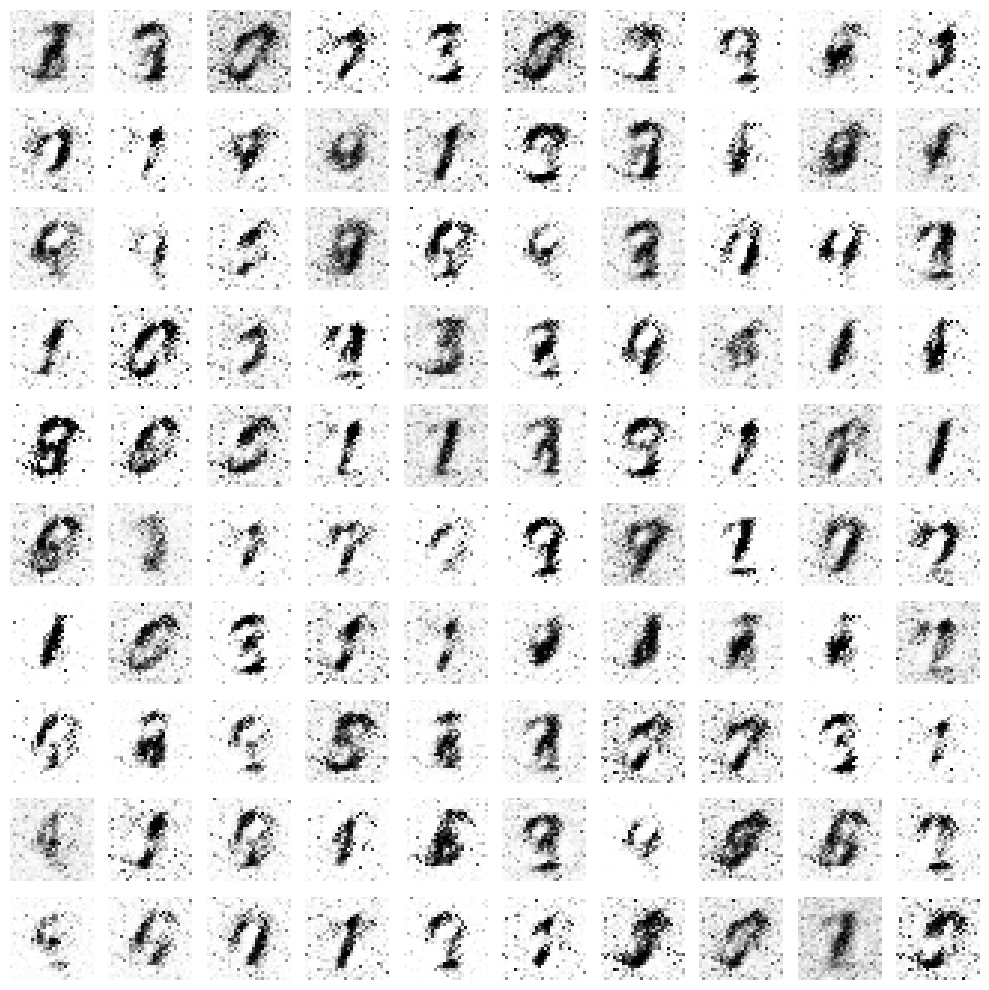

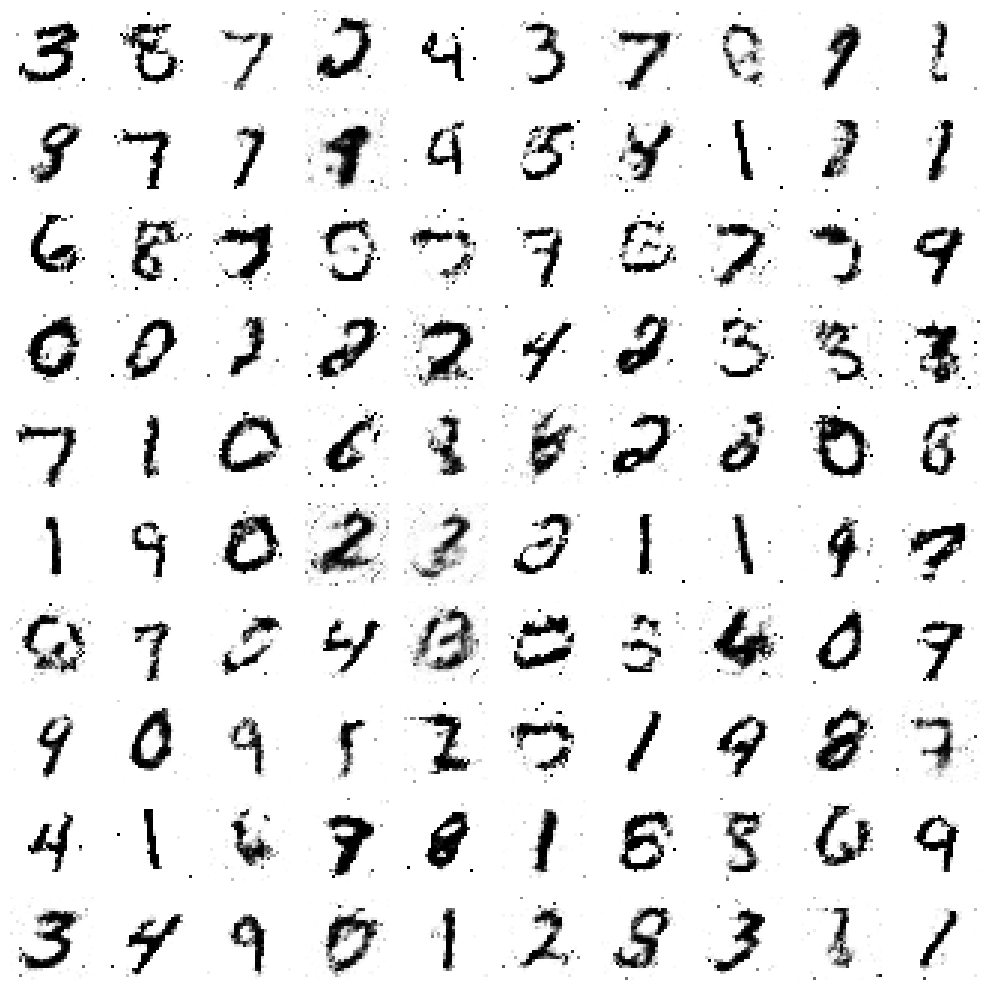

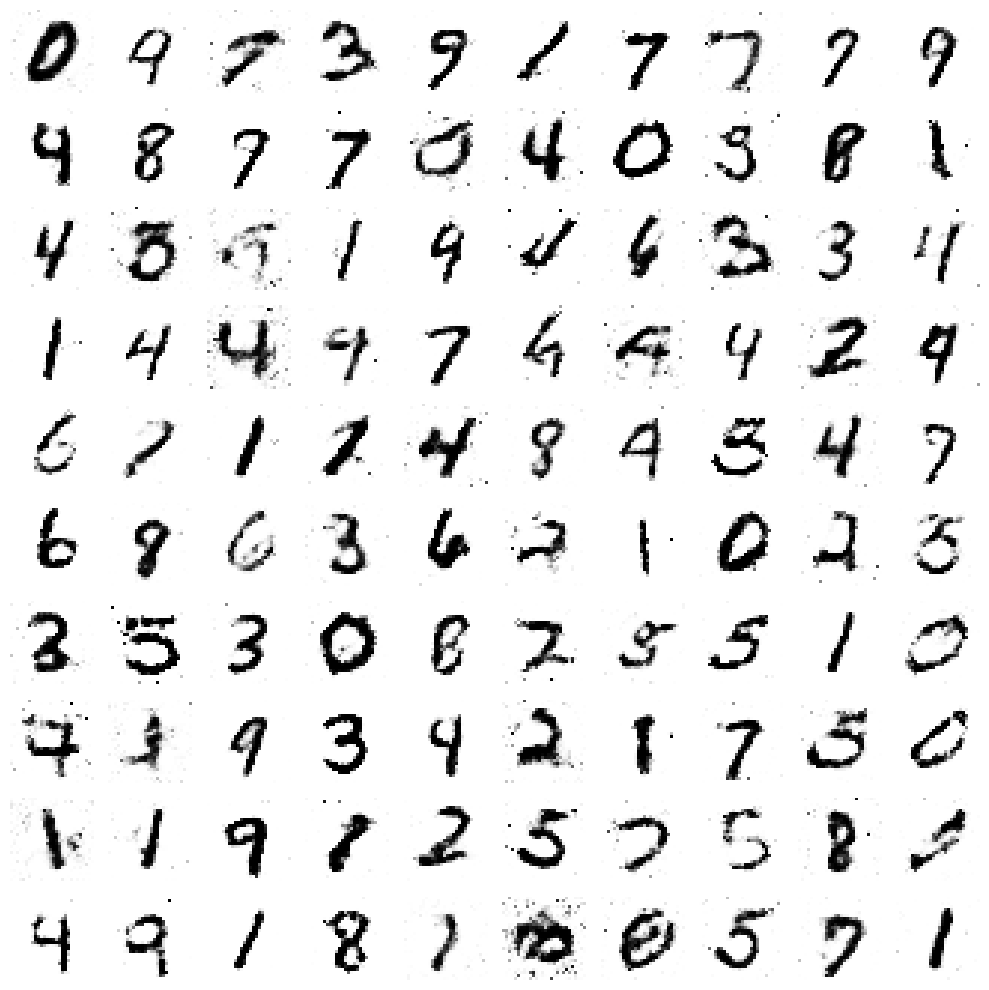

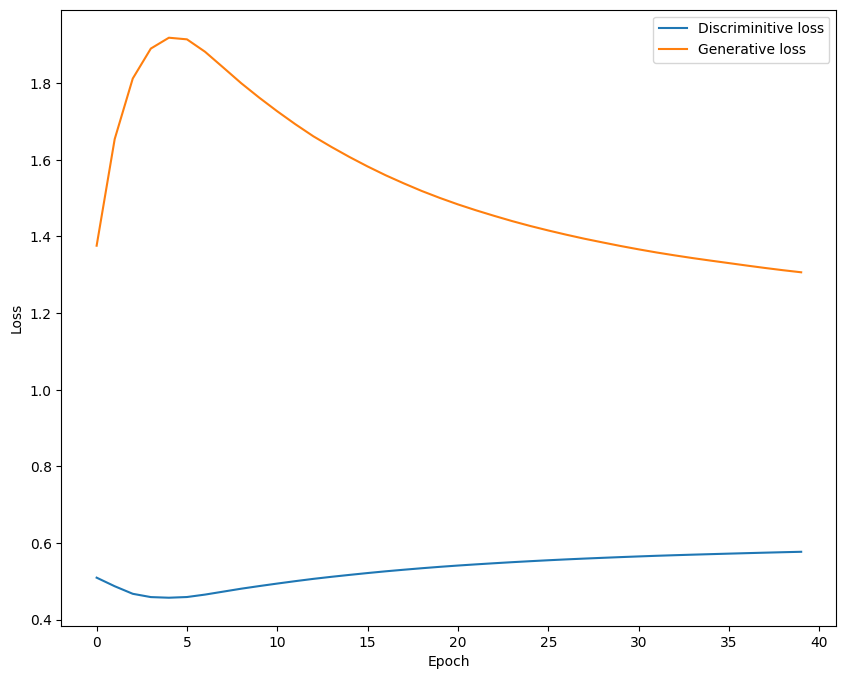

In [ ]:
import os
os.makedirs('images', exist_ok=True)

# train(200, 128) # orig
# attempt to reduce elapsed time but
# there are compromises between training and computation
# train(20, 128)
train(40, 128)
# train(100, 400)
# train(10, 128) # initially did not change learning rate but prob should
# test to help gen a plot of all images as one
# - Future nice to have but requires refactoring
# tested with imageGenStep to print 2 images from 2 epochs
# train(2, 128, 2)


In [ ]:
# import shutil
# from google.colab import files
# # import time
# # from google.colab import runtime

# # Compress the 'images' directory into a zip file
# shutil.make_archive('images', 'zip', 'images')

# # Now download the created zip file
# files.download(f'images.zip')

# # # Wait for a few seconds to allow the download to initiate in the browser
# # time.sleep(30)

# # # Disconnect the active runtime after the download is initiated
# # runtime.unassign()

In [ ]:
# This disconnects from the active runtime to avoid
# incurring idle charges after model is trained.

# from google.colab import runtime
# runtime.unassign()